In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)

# Section 3: Beta4-IRT and the CLAIRE Workflow

This section connects the workshop to the two research papers. Beta4-IRT extends Beta3-IRT by separating the sign and magnitude of discrimination, and CLAIRE uses Beta4-IRT on an agreement-based response matrix to evaluate models.


## Paper-Aligned Message

The CLAIRE paper frames the key idea as follows:

- the **response matrix** is built from model agreement;
- **model ability** is high when a model agrees well on difficult items;
- **instance difficulty** is high when only the good models agree on that instance.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from birt import Beta4

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

from sklearn.metrics import (
    # external validation
    adjusted_rand_score,
    mutual_info_score,
    # internal validation
    silhouette_score,
    calinski_harabasz_score
)

from utils.transform import TransformPairwise
from utils.handson import (
    make_beta4_item_bank,
    plot_beta4_iccs,
)


## Step 1: Beta4-IRT item bank

In the Beta4 formulation, abilities and difficulties are bounded in `(0, 1)`, and discrimination is written as the product of a sign term and a magnitude term.


In [3]:
beta4_bank_neg = make_beta4_item_bank(
    [
        {
            "item": "case_1",
            "difficulty": 0.15,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_2",
            "difficulty": 0.50,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_3",
            "difficulty": 0.82,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
    ]
)
beta4_bank_pos = make_beta4_item_bank(
    [
        {
            "item": "case_1",
            "difficulty": 0.15,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_2",
            "difficulty": 0.50,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_3",
            "difficulty": 0.82,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },

    ]
)

beta4_bank = pd.concat([beta4_bank_neg, beta4_bank_pos], ignore_index=True)

In [4]:
beta4_bank

,item,difficulty,discrimination_sign,discrimination_magnitude,effective_discrimination
0,case_1,0.15,-0.5,5,-2.5
1,case_2,0.50,-0.5,5,-2.5
2,case_3,0.82,-0.5,5,-2.5
3,case_1,0.15,0.5,5,2.5
4,case_2,0.50,0.5,5,2.5
5,case_3,0.82,0.5,5,2.5


## Step 2: Show how Beta4 changes curve shapes

The paper emphasizes that Beta-family models can express richer shapes than the usual logistic ICCs. Here we keep the example small and visual.


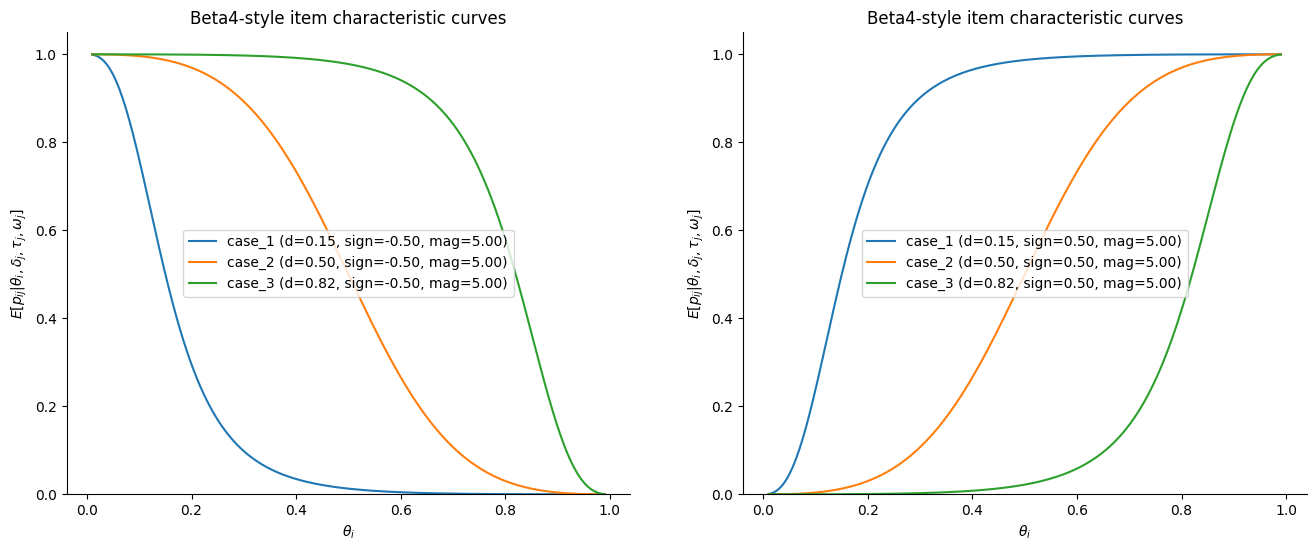

In [5]:
theta_grid = np.linspace(0.01, 0.99, 300)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
plot_beta4_iccs(
    beta4_bank_neg,
    theta=theta_grid,
    ax=ax[0]
)
plot_beta4_iccs(
    beta4_bank_pos,
    theta=theta_grid,
    ax=ax[1]
)
for _ax in ax:
    _ax.spines[["top", "right"]].set_visible(False)
plt.show()


In [6]:
# # difficulty, discrimination_sign, discrimination_magnitude, effective_discrimination
# fig, ax = plt.subplots(1, 1, figsize=(16, 8))
# ax = plot_beta4_family(
#     parameter_pairs=[
#         # (0.5, 0, 0, -2),
#         # (0.5, 0, 0, -1),
#         # (0.5, 0, 0, -0.5),
#         (0.5, 0.5, 6, None),
#         (0.5, 0.5, 4, None),
#         (0.5, 0.5, 2, None),
#     ],
#     theta=theta_grid,
#     ax=ax
# )
# plt.show()


## Step 3: Simulate Beta4 responses for a small model pool

This gives us a toy latent-ability setting.

### 3.1) Creating the dataset

In this step, it will be create the dataset based on each distribution for each parameter

$$
p_{ij} \sim \Beta(\alpha_{ij}, \beta_{ij}),
$$

$$
\alpha_{ij} = \bigg(\frac{\theta_i}{\delta_j}\bigg)^{aj}, \text{ } \beta_{ij} = \bigg(\frac{1 - \theta_i}{1 - \delta_j}\bigg)^{aj}, 
$$

$$
\theta_i \sim \Beta(1, 1), \text{ } \delta_j \sim \Beta(1, 1), \text{ } a_j \sim N(1, \sigma_{0}^{2})
$$

In [7]:
# setting some parameters to the toy dataset and the number of models 
sigma0 = 1
n_models = 10
n_instances = 300

In [8]:
thetai = np.random.beta(
    a=1,
    b=1,
    size=n_models
)
deltaj = np.random.beta(
    a=1,
    b=1,
    size=n_instances
)
aj = np.random.normal(
    loc=1,
    scale=sigma0,
    size=n_instances
)

In [9]:
alphaij, betaij, pij = (
    np.zeros((thetai.shape[0], deltaj.shape[0])),
    np.zeros((thetai.shape[0], deltaj.shape[0])),
    np.zeros((thetai.shape[0], deltaj.shape[0]))
)

In [10]:
for i in range(thetai.shape[0]):
    for j in range(deltaj.shape[0]):
        alphaij[i, j] = (thetai[i] / deltaj[j]) ** aj[j]
        betaij[i, j] = ((1 - thetai[i]) / (1 - deltaj[j])) ** aj[j]
        pij[i, j] = np.mean(
            np.random.beta(
                a = alphaij[i, j],
                b = betaij[i, j],
                size = 100
            )
        )
        
pij = pd.DataFrame(
    pij,
    index=[f'model_{i}' for i in range(n_models)],
    columns=[f'instance_{j}' for j in range(deltaj.shape[0])]
)

In [11]:
pij.shape

(10, 300)

### 3.2) Training the beta4

In this step, we will train the beta4 model. The parameters used are show in the code.

In [12]:
birt = Beta4(
    learning_rate=1, 
    epochs=10_000,
    n_respondents=pij.shape[0], 
    n_items=pij.shape[1],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True
)
birt.fit(pij.T.values)

/Users/manuelfjr/Library/Caches/pypoetry/virtualenvs/latent-ability-ml-gUy-rFEi-py3.13/lib/python3.13/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/manuelfjr/Library/Caches/pypoetry/virtualenvs/latent-ability-ml-gUy-rFEi-py3.13/lib/python3.13/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 10000/10000 [00:34<00:00, 293.51it/s]


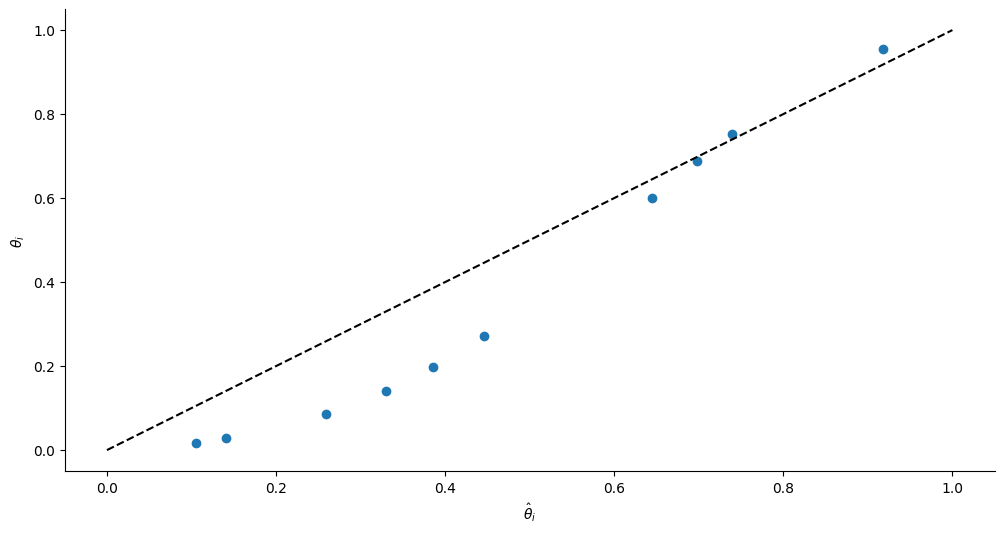

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.abilities,
    thetai
)
ax.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{\theta}_i$")
ax.set_ylabel(r"$\theta_i$")
plt.show()

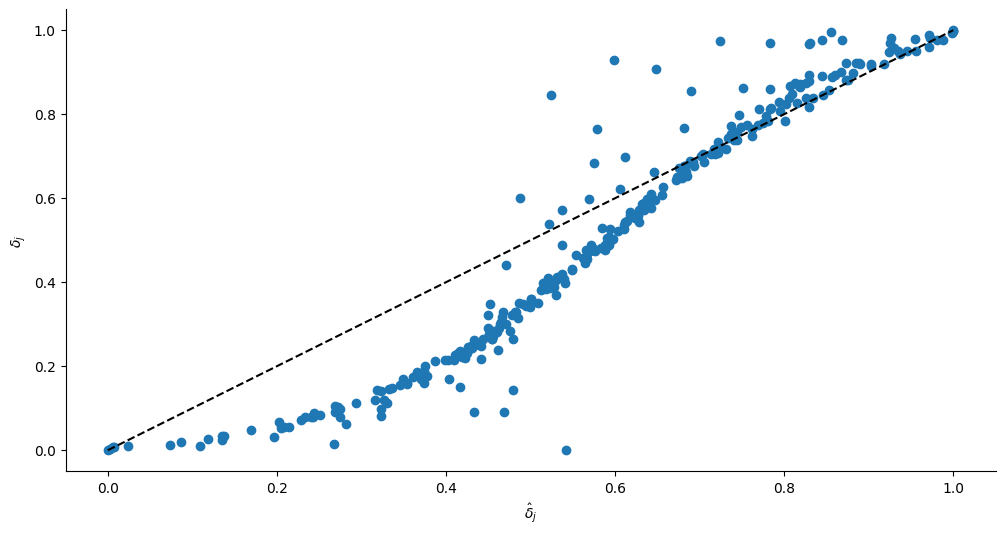

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.difficulties,
    deltaj
)
ax.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{\delta}_j$")
ax.set_ylabel(r"$\delta_j$")
plt.show()

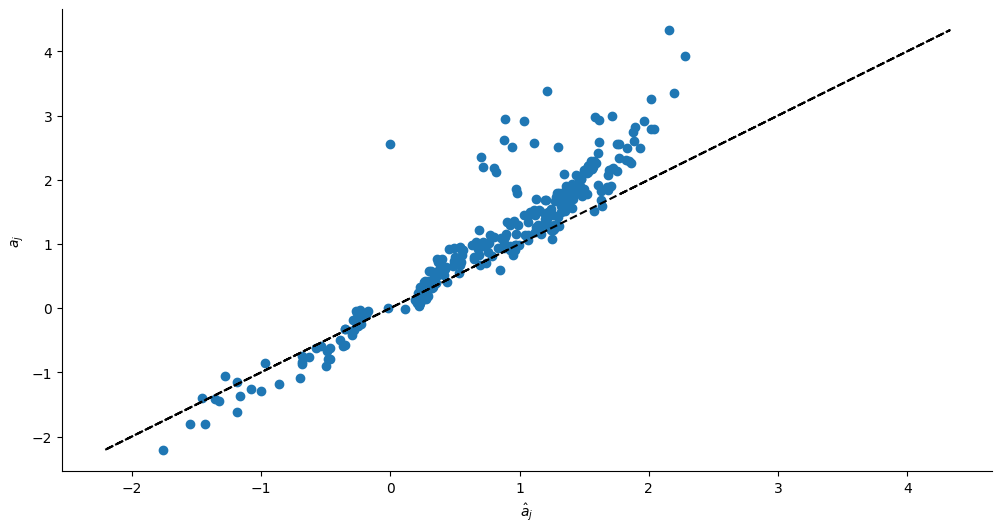

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.discriminations,
    aj
)
ax.plot(
    aj,
    aj,
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{a}_j$")
ax.set_ylabel(r"$a_j$")
plt.show()

## Step 4: CLAIRE's agreement-based response matrix

In the CLAIRE paper, responses are not obtained from ground truth labels. Instead, each response is built from how much a model agrees with the rest of the pool on each instance.

In this section, we will split in steps until to use CLAIRE to evaluate model and estimate the item difficulty and item discrimination.

1. **First,** we will use a generated toy problem;

2. **Second,** we will train some models (They will be listed in the codes.);

3. **Third,** the label provide for each model will be save;

4. After all points bellow, it will be create the responde matrix based on aggrements between the models about how to cluster each pair of instance.

5. **Finally,** it will be train a Beta4-IRT to get the ability of each model,  the discrimination and difficulty of the item

### 4.1) Toy problem

In [16]:
# X, y = make_blobs(
#     n_samples=500,
#     centers=[[0.3, 0.3], [0.55, 0.6]],
#     cluster_std=0.1,
#     random_state=1
    
# )
X, y = make_blobs(
    n_samples=500,
    random_state=170,
    cluster_std=[1.0, 2.5, 0.5]
)

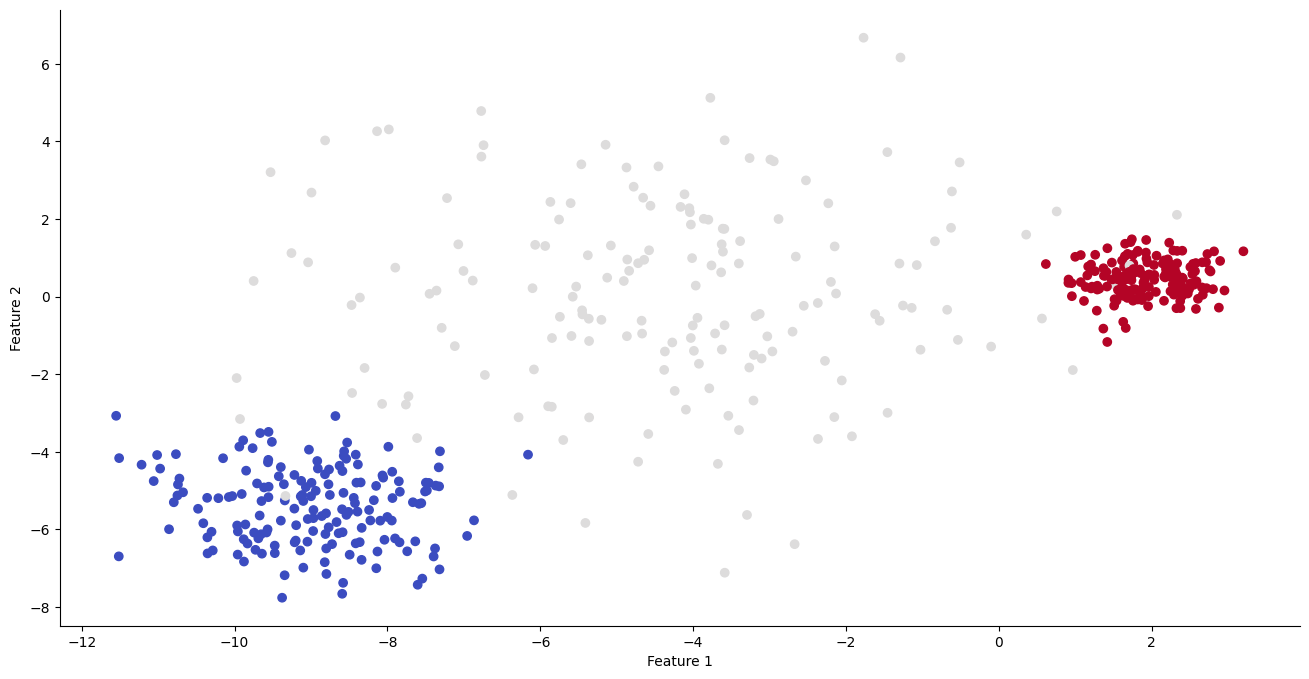

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap='coolwarm'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"Feature 1")
ax.set_ylabel(r"Feature 2")
plt.show()

### 4.2) Training a pool of model and save the label

In [18]:
from sklearn.cluster import MeanShift, OPTICS
models = {
    **{
        f"KMeans_n_clusters_{i}_random_state_1": KMeans(
            n_clusters=i, random_state=1
        )
        for i in range(1, 8 + 1)
    },
    **{
        f"DBSCAN_eps_{eps:.2f}_min_samples_5": DBSCAN(
            eps=float(eps), min_samples=5
        )
        for eps in np.linspace(0.1, 0.9, 9)
    },
    **{
        f"SpectralClustering_n_clusters_{i}_random_state_1": SpectralClustering(
            n_clusters=i, random_state=1
        )
        for i in range(1, 8 + 1)
    },
    **{
        f"MeanShift": MeanShift(),
    },
    **{
        f"OPTICS_min_samples_5": OPTICS(),
    }
}


In [19]:
len(models.keys())

27

In [20]:
results = []
partitions = pd.DataFrame(columns=models.keys())
for key, model in models.items():
    model.fit(X)
    partitions[key] = model.labels_
    metrics = {
        "model": key, 
        "adjusted_rand_score": adjusted_rand_score(y, model.labels_),
        "mutual_info_score": mutual_info_score(y, model.labels_),
    }
    try:
        metrics = metrics | {
            "silhouette_score": silhouette_score(X, model.labels_),
            "calinski_harabasz_score": calinski_harabasz_score(X, model.labels_)
        }
    except:
        metrics = metrics | {
            "silhouette_score": None,
            "calinski_harabasz_score": None
        }
        pass
    results.append(
        metrics
    )
    results
results = pd.DataFrame(results)

In [21]:
results.head()

,model,adjusted_rand_score,mutual_info_score,silhouette_score,calinski_harabasz_score
0,KMeans_n_clusters_1_random_state_1,0.000000,0.000000,NaN,NaN
1,KMeans_n_clusters_2_random_state_1,0.450321,0.468602,0.621491,1288.298274
2,KMeans_n_clusters_3_random_state_1,0.791996,0.853866,0.655190,1851.018470
3,KMeans_n_clusters_4_random_state_1,0.776396,0.939627,0.586943,1491.329221
4,KMeans_n_clusters_5_random_state_1,0.690697,0.907159,0.519137,1469.272914


### 4.3) Create the response matrix

In [22]:
partitions.head()

,KMeans_n_clusters_1_random_state_1,KMeans_n_clusters_2_random_state_1,KMeans_n_clusters_3_random_state_1,KMeans_n_clusters_4_random_state_1,KMeans_n_clusters_5_random_state_1,KMeans_n_clusters_6_random_state_1,KMeans_n_clusters_7_random_state_1,KMeans_n_clusters_8_random_state_1,DBSCAN_eps_0.10_min_samples_5,DBSCAN_eps_0.20_min_samples_5,...,SpectralClustering_n_clusters_1_random_state_1,SpectralClustering_n_clusters_2_random_state_1,SpectralClustering_n_clusters_3_random_state_1,SpectralClustering_n_clusters_4_random_state_1,SpectralClustering_n_clusters_5_random_state_1,SpectralClustering_n_clusters_6_random_state_1,SpectralClustering_n_clusters_7_random_state_1,SpectralClustering_n_clusters_8_random_state_1,MeanShift,OPTICS_min_samples_5
0,0,1,2,2,2,2,2,2,-1,0,...,0,1,2,3,0,0,0,0,0,0
1,0,1,2,2,2,2,2,6,-1,0,...,0,1,2,3,0,0,0,0,0,5
2,0,1,0,3,3,3,0,3,-1,-1,...,0,1,2,2,4,4,4,5,2,10
3,0,1,2,2,2,2,2,2,-1,-1,...,0,1,2,3,0,0,0,0,0,-1
4,0,0,1,1,1,1,1,1,-1,-1,...,0,0,0,0,0,0,0,0,1,-1


In [23]:
tp = TransformPairwise(1)
pij = tp.generate_pij_matrix(partitions)
pij.head()

100%|██████████| 500/500 [00:01<00:00, 373.39it/s]


,KMeans_n_clusters_1_random_state_1,KMeans_n_clusters_2_random_state_1,KMeans_n_clusters_3_random_state_1,KMeans_n_clusters_4_random_state_1,KMeans_n_clusters_5_random_state_1,KMeans_n_clusters_6_random_state_1,KMeans_n_clusters_7_random_state_1,KMeans_n_clusters_8_random_state_1,DBSCAN_eps_0.10_min_samples_5,DBSCAN_eps_0.20_min_samples_5,...,SpectralClustering_n_clusters_1_random_state_1,SpectralClustering_n_clusters_2_random_state_1,SpectralClustering_n_clusters_3_random_state_1,SpectralClustering_n_clusters_4_random_state_1,SpectralClustering_n_clusters_5_random_state_1,SpectralClustering_n_clusters_6_random_state_1,SpectralClustering_n_clusters_7_random_state_1,SpectralClustering_n_clusters_8_random_state_1,MeanShift,OPTICS_min_samples_5
0,0.455758,0.703946,0.800062,0.807924,0.806305,0.807384,0.808078,0.680592,0.378449,0.759982,...,0.455758,0.649376,0.645984,0.808540,0.629567,0.629721,0.628873,0.623863,0.803916,0.517497
1,0.454602,0.702790,0.798906,0.806613,0.804995,0.806228,0.806459,0.645059,0.378526,0.758363,...,0.454602,0.648220,0.644828,0.807076,0.628102,0.628257,0.627409,0.622399,0.802759,0.517342
2,0.274934,0.531756,0.741637,0.702482,0.739402,0.709342,0.733621,0.710498,0.333899,0.496686,...,0.274934,0.537305,0.535918,0.732388,0.743102,0.740404,0.739325,0.739864,0.746108,0.701865
3,0.494450,0.689918,0.765685,0.770310,0.770079,0.769924,0.769847,0.641745,0.423616,0.278711,...,0.494450,0.646601,0.643826,0.770926,0.631725,0.631879,0.631340,0.626946,0.768614,0.527979
4,0.445969,0.733313,0.786342,0.788423,0.759596,0.674965,0.685140,0.674426,0.496763,0.533452,...,0.445969,0.782488,0.785879,0.791275,0.631031,0.631185,0.630029,0.627332,0.786342,0.472561


### 4.4) Train the beta4-IRT using the response matrix

In [24]:
birt = Beta4(
    learning_rate=1, 
    epochs=10_000,
    n_respondents=pij.shape[1], 
    n_items=pij.shape[0],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True
)
birt.fit(pij.values)

 24%|██▎       | 2366/10000 [00:10<00:35, 213.85it/s]

Model converged at the 2388th epoch


 24%|██▍       | 2388/10000 [00:10<00:32, 233.15it/s]


In [25]:
birt.summary()


        ESTIMATES
        -----
                        | Min      1Qt      Median   3Qt      Max      Std.Dev
        Ability         | 0.28640  0.44098  0.46176  0.53732  0.54843  0.07892
        Difficulty      | 0.30232  0.32805  0.33982  0.35706  0.46310  0.02768
        Discrimination  | 0.52665  0.84971  0.90098  0.91402  0.93325  0.06929
        pij             | 0.35862  0.56957  0.61832  0.66598  0.71556  0.07474
        -----
        Pseudo-R2       | 0.78718
        


## Step 5: From agreement to ability ranking

In the full CLAIRE pipeline from the paper, Beta4-IRT is fitted to this response matrix to estimate abilities, difficulties, and discriminations. In this classroom notebook, we keep the *same workflow structure* but use a lightweight latent-aware summary so students can inspect the logic without a heavy optimizer.


In [26]:
abilities = pd.DataFrame(
    {
        "model": partitions.columns,
        "abis": birt.abilities
    }
).sort_values("abis", ascending=False)

In [27]:
data_join = results.merge(
    abilities, on="model"
).sort_values("abis", ascending=False)


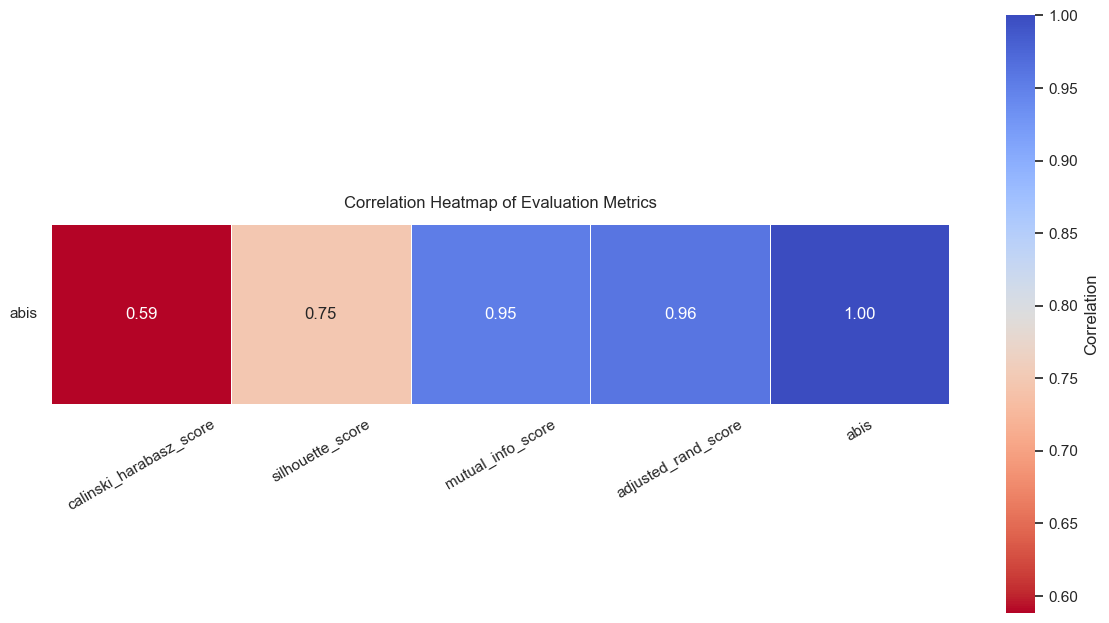

In [28]:
corr = data_join.set_index("model").corr()

sns.set_theme(style="white")
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

sns.heatmap(
    corr.loc[["abis"], : ].sort_values("abis", axis=1),
    ax=ax,
    #cmap="", 
    # use other color, that can be express good the transition from negative to positive correlations
    cmap=sns.color_palette("coolwarm_r", as_cmap=True),
    vmin=corr.loc[["abis"], : ].values.min(), vmax=corr.loc[["abis"], : ].values.max(), #center=(corr.values.min() + corr.values.max()) / 2,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Correlation", "shrink": 0.9}
)

ax.set_title("Correlation Heatmap of Evaluation Metrics", pad=12)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## Step 6: Inspect the difficulty of the dataset 

in this section, we will inspect the latent difficulty of the dataset as estimated by BIRT, and see if it aligns with our intuition about the dataset.

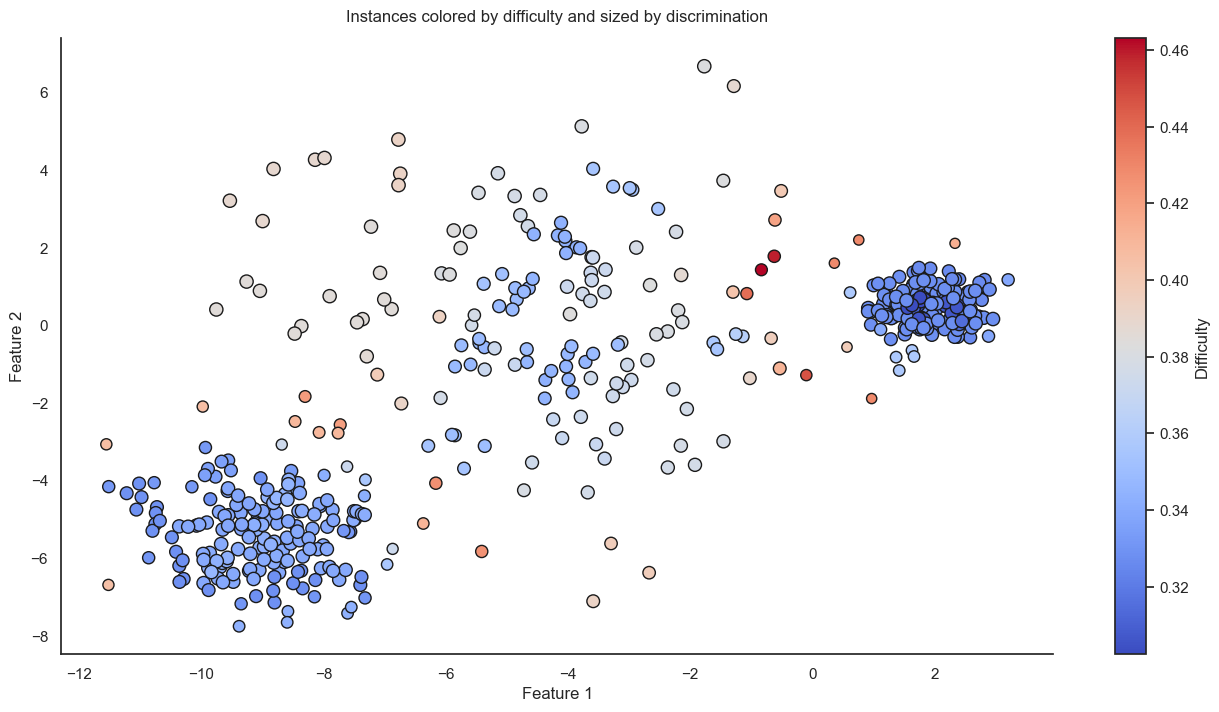

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

sizes = np.clip(np.abs(birt.discriminations) * 120, 20, None)

sc = ax.scatter(
    X[:, 0],
    X[:, 1],
    c=birt.difficulties,
    cmap="coolwarm",
    s=birt.discriminations * 100,
    edgecolor="k"
)

fig.colorbar(sc, ax=ax, label="Difficulty")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Instances colored by difficulty and sized by discrimination", pad=12)

plt.show()

bellow, it is inspect the ICC for the most easy and most difficulty instance to the dataset

In [30]:
thetai = np.linspace(0.01, 0.99, 300)
instance = {
    "most_difficult": {
        "difficulty": birt.difficulties.max(),
        "discrimination": birt.discriminations[np.where(birt.difficulties == birt.difficulties.max())[0][0]]
    },
    "most_easy": {
        "difficulty": birt.difficulties.min(),
        "discrimination": birt.discriminations[np.where(birt.difficulties == birt.difficulties.min())[0][0]]
    }
}

In [ ]:
from utils.handson import beta4_expected_response
instance["most_difficult"]["hard"] = beta4_expected_response(
    theta=thetai,
    difficulty=instance["most_difficult"]["difficulty"],
    discrimination_sign=np.sign(instance["most_difficult"]["discrimination"]),
    discrimination_magnitude=np.abs(instance["most_difficult"]["discrimination"])
)
instance["most_easy"]["easy"] = beta4_expected_response(
    theta=thetai,
    difficulty=instance["most_easy"]["difficulty"],
    discrimination_sign=np.sign(instance["most_easy"]["discrimination"]),
    discrimination_magnitude=np.abs(instance["most_easy"]["discrimination"])
)

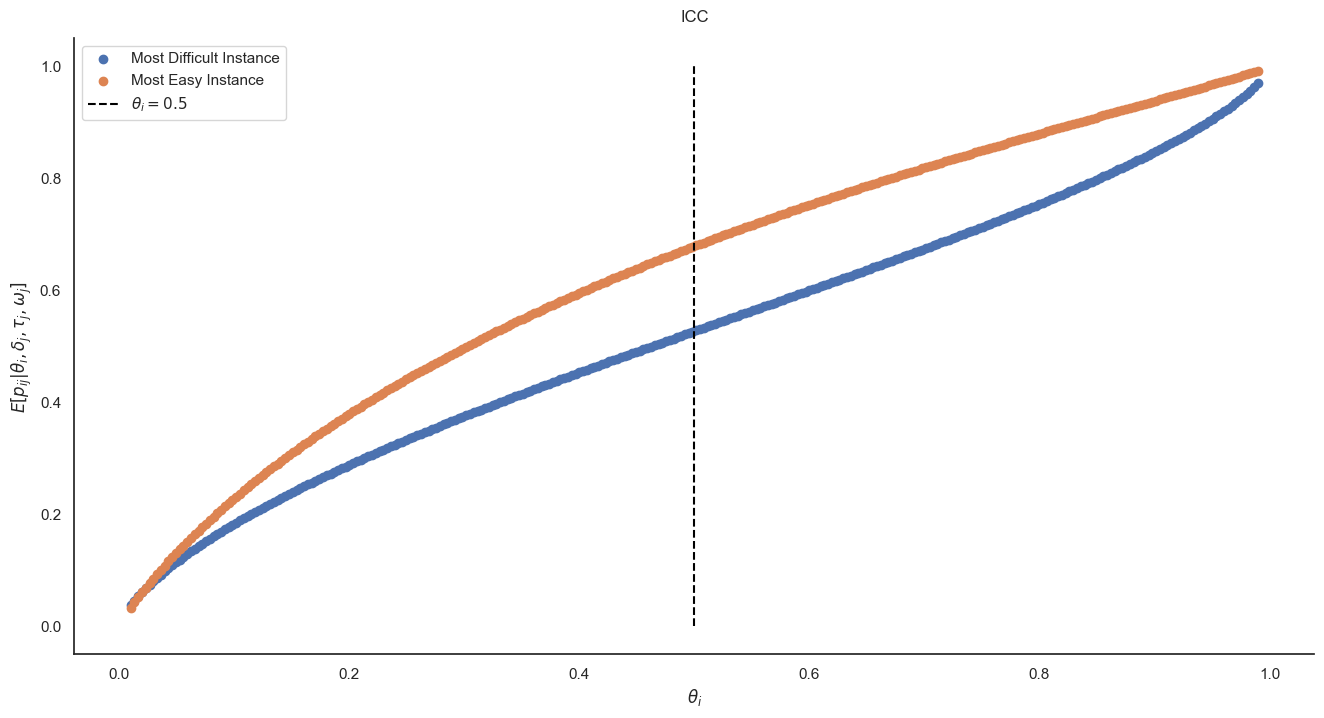

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

ax.scatter(
    thetai,
    instance["most_difficult"]["hard"],
    label="Most Difficult Instance"
)
ax.scatter(
    thetai,
    instance["most_easy"]["easy"],
    label="Most Easy Instance"
)
ax.vlines(
    0.5,
    ymin=0,
    ymax=1,
    color='black',
    linestyle='--',
    label=r"$\theta_i = 0.5$"
)
ax.set_xlabel(r"$\theta_i$")
ax.set_ylabel(r"$E[p_{ij} | \theta_i, \delta_{j}, \tau_j, \omega_j]$")
ax .set_title("ICC", pad=12)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Discussion Prompts

- Which instances seem difficult because models disagree more?
- Which model looks strongest once difficult instances receive more importance?
- Why is this different from simply averaging agreement across all items?
- Why is Beta4-IRT a natural fit when responses are proportions rather than binary outcomes?


## Closing Message

Beta4-IRT gives us a bounded and flexible latent-response model, and CLAIRE shows how to build a meaningful response matrix even when ground truth is unavailable. That is the core research bridge from classical evaluation to latent ability.
